获取数据

In [1]:
from itertools import groupby

import pandas as pd
# from win_unicode_console.raw_input import original_input

df1 = pd.read_excel("D:/PythonProject/online+retail+ii/online_retail_II.xlsx", sheet_name="Year 2009-2010")
df2 = pd.read_excel("D:/PythonProject/online+retail+ii/online_retail_II.xlsx", sheet_name="Year 2010-2011")
df=pd.concat([df1,df2],ignore_index=True)

# 1. 先看一下当前的字段名，确认和教程一致
print("当前字段名：", df.columns.tolist())

# 2. 字段名统一（你的数据已经是标准的，这里可以直接确认，不需要改）
# 教程里的字段：Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country

# 3. 数据类型转换
# ① 把 Customer ID 转为 Int64（支持缺失值，避免变成浮点数）
df['Customer ID'] = df['Customer ID'].astype('Int64')

# ② 把 InvoiceDate 转为 datetime 时间格式
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 检查转换结果
print("数据类型：\n", df.dtypes)

当前字段名： ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
数据类型：
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             Int64
Country                object
dtype: object


缺失值处理

In [2]:
# 1. 先统计一下原始数据量
original_count=len(df)
print(f'清洗前总行数：{original_count}')

# 2. 删除 Customer ID 为空的行（这些数据无法归属用户，无法做用户分析）
df_clean=df.dropna(subset=['Customer ID']).copy()
# 第二步：再过滤掉 空字符串/纯空格 的假缺失值（补充保险）
df_clean = df_clean[df_clean['Customer ID'].astype(str).str.strip() != '']

# 3. 统计删除了多少条，方便后面写报告/面试说明
deleted_count=original_count-len(df_clean)
deleted_percent=(deleted_count/original_count)*100
print(f"清洗后总行数：{len(df_clean)}")
print(f"删除的行数：{deleted_count}，占比：{deleted_percent:.2f}%")

清洗前总行数：1067371
清洗后总行数：824364
删除的行数：243007，占比：22.77%


异常与退货处理

In [3]:
df['is_return']=df['Quantity']<0|df['Invoice'].astype( str).str.startswith('C')
# 查看一下有多少退货订单
return_count=df['is_return'].sum()
print(f"退货订单数：{return_count}")
#求退货率
total_count=len(df)   #总订单数
print(f'总订单数：{total_count}')

return_rate=(return_count/total_count)*100
print(f"退货率：{return_rate:.2f}%")

退货订单数：22950
总订单数：1067371
退货率：2.15%


数值异常值（运用IQR方法和99分位数方法）

In [4]:
# 先筛选出正常订单（非退货），再处理异常值
df_normal = df[df['is_return'] == False].copy()
# 定义一个IQR异常值检测函数
def mark_outliers(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    up=q3+10*iqr
    low=q1-10*iqr
    #标记异常值
    df[f'{column}_is_outlier']=(df[column]>up)|(df[column]<low)
    return  df
# 对Quantity和Price列分别标记异常值
df_normal=mark_outliers(df_normal,'Quantity')
df_normal=mark_outliers(df_normal,'Price')
# 查看异常订单数量
print('异常Quantity订单的数量：',df_normal['Quantity_is_outlier'].sum())
print('异常Price订单的数量：',df_normal['Price_is_outlier'].sum())
# 后续分析用的干净数据（剔除所有异常）
df_clean=df_normal[(df_normal['Quantity_is_outlier']==False)&(df_normal['Price_is_outlier']==False)].copy()
print('异常订单剔除后，订单数量：',len(df_clean))

异常Quantity订单的数量： 10561
异常Price订单的数量： 3553
异常订单剔除后，订单数量： 1030307


计算订单金额

In [5]:
df_clean['TotalAmount']=df_clean['Quantity']*df_clean['Price']

时间范围裁剪

In [6]:
# 时间范围裁剪（只保留完整月份，保证分析准确）
start_date = pd.to_datetime('2009-12-01')   #开始时间
end_date = pd.to_datetime('2011-11-30')     #结束时间
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_final=df_clean[(df_clean['InvoiceDate']>=start_date)&(df_clean['InvoiceDate']<=end_date)].copy()
print('裁剪后的订单数量：',len(df_final))

裁剪后的订单数量： 1002054


生成月度汇总表

In [7]:
# 新增一列Month，格式为 年-月（如 2009-12）
df_final['Month']=df_final['InvoiceDate'].dt.to_period('M')
# 按月汇总，生成月度指标表
monthly_summary=df_final.groupby('Month').agg(
    GMV=('TotalAmount', 'sum'),     #计算每月 GMV（总销售额）
    订单数=('Invoice', 'nunique'),
    MAU=('Customer ID', 'nunique')
).reset_index()

# 3. 计算衍生指标：客单价
monthly_summary['客单价'] = monthly_summary['GMV'] / monthly_summary['订单数'].replace(0, 1)
print(monthly_summary.head())




     Month         GMV   订单数   MAU         客单价
0  2009-12  670620.600  1765   939  379.955014
1  2010-01  449676.992  1129   698  398.296716
2  2010-02  437866.876  1235   765  354.548078
3  2010-03  631459.571  1685  1033  374.753455
4  2010-04  560639.202  1453   927  385.849416


折线图

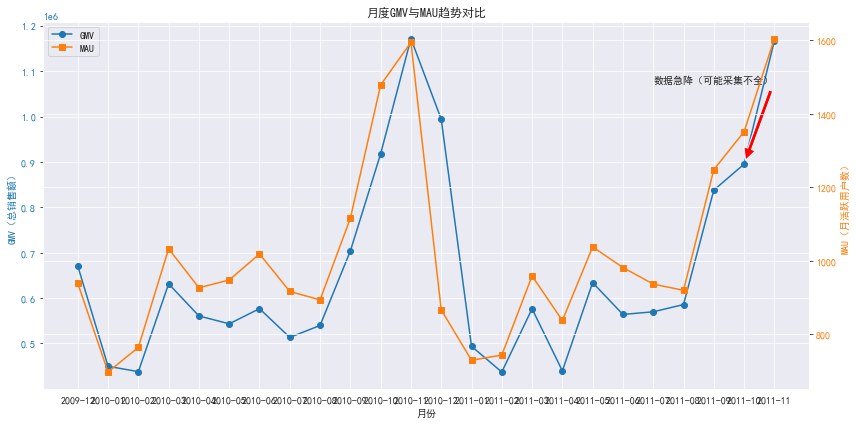

In [26]:
import matplotlib.pyplot as plt

# 设置中文显示，避免乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 转换Month为字符串，方便绘图
monthly_summary['Month_str'] = monthly_summary['Month'].astype(str)

# 创建画布和双轴
fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴：GMV折线
color = 'tab:blue'
ax1.set_xlabel('月份')
ax1.set_ylabel('GMV（总销售额）', color=color)
line1 = ax1.plot(monthly_summary['Month_str'], monthly_summary['GMV'], color=color, marker='o', label='GMV')
ax1.tick_params(axis='y', labelcolor=color)

# 右轴：MAU折线
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('MAU（月活跃用户数）', color=color)
line2 = ax2.plot(monthly_summary['Month_str'], monthly_summary['MAU'], color=color, marker='s', label='MAU')
ax2.tick_params(axis='y', labelcolor=color)

# 标注波动点（比如2011-10）
# 找到2011-10的索引
drop_point = monthly_summary[monthly_summary['Month_str'] == '2011-10'].index[0]
ax1.annotate('数据急降（可能采集不全）',
             xy=(drop_point, monthly_summary.loc[drop_point, 'GMV']),
             xytext=(drop_point-3, monthly_summary.loc[drop_point, 'GMV']*1.2),
             arrowprops=dict(facecolor='red', shrink=0.05))

# 合并图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('月度GMV与MAU趋势对比')
plt.xticks(rotation=45)
plt.tight_layout()
#导出图片
plt.savefig('用户分层GMV贡献.png', dpi=300, bbox_inches='tight')
plt.show()

复购率

In [9]:
# 1. 统计每个用户的订单数
user_order_count = df_final.groupby('Customer ID')['Invoice'].nunique().reset_index()
user_order_count.columns = ['Customer ID', '订单数']
# 2. 计算复购率
# 总用户数（至少购买1次）
total_users = len(user_order_count)
# 复购用户数（购买次数>1）
repeat_users = len(user_order_count[user_order_count['订单数'] > 1])
# 复购率
repurchase_rate = repeat_users / total_users

print("===== 用户复购率 =====")
print(f"总用户数：{total_users}")
print(f"复购用户数：{repeat_users}")
print(f"整体复购率：{repurchase_rate:.2%}")

===== 用户复购率 =====
总用户数：5773
复购用户数：4126
整体复购率：71.47%


In [23]:
# 导出为Excel文件
monthly_summary.to_excel("月度经营指标汇总.xlsx", index=False)
print("✅ 月度经营指标汇总已导出为：月度经营指标汇总.xlsx")


✅ 月度经营指标汇总已导出为：月度经营指标汇总.xlsx


In [28]:
import pandas as pd

# ------------------------------
# 1. 先把时间列转成字符串（解决所有时间类型兼容问题）
# ------------------------------
df_final_export = df_final.copy()
# 把Timestamp格式转成字符串，格式：年-月-日 时:分:秒
df_final_export['InvoiceDate'] = df_final_export['InvoiceDate'].dt.strftime('%Y-%m-%d %H:%M:%S')

# ------------------------------
# 2. 按年份拆分数据，和原始文件结构一致
# ------------------------------
df_2009_2010 = df_final_export[(df_final_export['InvoiceDate'] >= '2009-12-01') &
                               (df_final_export['InvoiceDate'] <= '2010-12-31')].copy()
df_2010_2011 = df_final_export[(df_final_export['InvoiceDate'] >= '2011-01-01') &
                               (df_final_export['InvoiceDate'] <= '2011-11-30')].copy()

# ------------------------------
# 3. 改用xlsxwriter引擎导出（稳定不报错）
# ------------------------------
with pd.ExcelWriter("清洗后_电商数据.xlsx", engine="xlsxwriter") as writer:
    # 第一个Sheet：2009-2010数据
    df_2009_2010.to_excel(writer, sheet_name="Year 2009-2010", index=False)
    # 第二个Sheet：2010-2011数据
    df_2010_2011.to_excel(writer, sheet_name="Year 2010-2011", index=False)

print("✅ 导出成功！文件：清洗后_电商数据.xlsx")
print("✅ 包含2个Sheet，和原始文件结构完全一致")

✅ 导出成功！文件：清洗后_电商数据.xlsx
✅ 包含2个Sheet，和原始文件结构完全一致


In [25]:
print(df_final.columns.tolist())


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'is_return', 'Quantity_is_outlier', 'Price_is_outlier', 'TotalAmount', 'Month']


构建用户特征表（RFM 基础）

In [10]:
# 以Customer ID分组，计算用户特征
user_features=df_final.groupby('Customer ID').agg(
    # 首购日期
    first_purchase=('InvoiceDate', 'min'),
    # 最近购买日期
     last_purchase=('InvoiceDate', 'max'),
    # 累计购买次数（订单数）
    frequency=('Invoice', 'nunique'),
    # 累计消费金额
    monetary=('TotalAmount', 'sum')
).reset_index()
# 计算用户生命周期（天）：最后购买日期 - 首次购买日期
user_features['用户生命周期（天）']=(user_features['last_purchase']-user_features['first_purchase']).dt.days
# 1. 先在原始清洗数据上，按用户分组计算平均购买间隔
def calc_avg_interval(dates):
    # 先排序日期，再计算相邻日期差
    dates = dates.sort_values()
    diffs = dates.diff().dropna()  # 去掉第一个NaN值
    if len(diffs) == 0:
        return None  # 只有1个订单的用户，无法计算间隔
    diff_days = diffs.dt.days
    return diff_days.mean()  # 取天数的平均值

# 用df_final（原始清洗数据）计算，而不是user_features
avg_interval = df_final.groupby('Customer ID')['InvoiceDate'].apply(calc_avg_interval).reset_index(name='平均购买间隔（天）')

# 2. 再合并回user_features表
user_features = user_features.merge(avg_interval, on='Customer ID', how='left')

print(user_features.head())



   Customer ID      first_purchase       last_purchase  frequency  monetary  \
0        12346 2009-12-14 08:34:00 2010-06-28 13:53:00         11    372.86   
1        12347 2010-10-31 14:20:00 2011-10-31 12:25:00          7   5158.90   
2        12348 2010-09-27 14:59:00 2011-09-25 13:13:00          5   1057.24   
3        12349 2010-04-29 13:20:00 2011-11-21 09:51:00          3   3498.94   
4        12350 2011-02-02 16:01:00 2011-02-02 16:01:00          1    294.40   

   用户生命周期（天）  平均购买间隔（天）  
0        196   6.000000  
1        364   1.508333  
2        362  10.342857  
3        570   3.372781  
4          0   0.000000  


 同期群分析（Cohort Analysis）

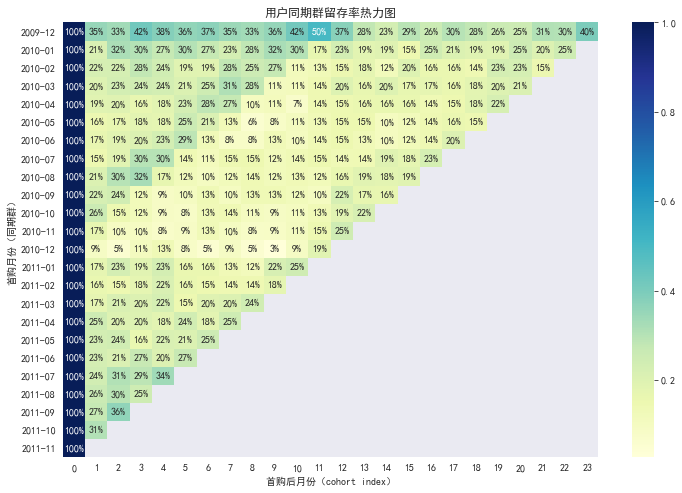

✅ 同期群留存率热力图已生成！


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========== 1. 彻底清理数据并生成同期群标签 ==========
# 只保留 Customer ID 不为空的行
df_clean = df_final[df_final['Customer ID'].notna()].copy()

# 强制转成字符串，避免后续合并报错
df_clean['Customer ID'] = df_clean['Customer ID'].astype(str)

# 计算每个用户的首购日期，并生成 2010-02 格式的字符串
user_cohort = df_clean.groupby('Customer ID')['InvoiceDate'].min().reset_index()
user_cohort['cohort_month'] = user_cohort['InvoiceDate'].dt.strftime('%Y-%m')

# 只保留需要的两列
user_cohort = user_cohort[['Customer ID', 'cohort_month']]

# 合并回原始订单表
df_clean = pd.merge(
    df_clean,
    user_cohort,
    on='Customer ID',
    how='left'
)

# ========== 2. 计算同期群索引 ==========
# 给每笔订单打上订单月份标签
df_clean['order_month'] = df_clean['InvoiceDate'].dt.strftime('%Y-%m')

# 把年月字符串转成数字，方便相减
def ym_to_num(s):
    if pd.isna(s):
        return None
    year, month = map(int, s.split('-'))
    return year * 12 + month

df_clean['order_num'] = df_clean['order_month'].apply(ym_to_num)
df_clean['cohort_num'] = df_clean['cohort_month'].apply(ym_to_num)

# 计算首购后第几个月
df_clean['cohort_index'] = df_clean['order_num'] - df_clean['cohort_num']

# ========== 3. 构建留存矩阵 ==========
# 去掉空值，避免 groupby 出错
df_clean = df_clean.dropna(subset=['cohort_month', 'cohort_index'])

cohort_data = df_clean.groupby(
    ['cohort_month', 'cohort_index']
)['Customer ID'].nunique().unstack()

# 计算留存率
cohort_sizes = cohort_data.iloc[:, 0]
retention_matrix = cohort_data.divide(cohort_sizes, axis=0)

# ========== 4. 绘制热力图 ==========
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('用户同期群留存率热力图')
plt.ylabel('首购月份（同期群）')
plt.xlabel('首购后月份（cohort index）')
# 保存图片
plt.savefig('同期群留存热力图.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 同期群留存率热力图已生成！")

6.1 定义参考日期

In [12]:
import datetime as dt    #我们要用它来处理日期差、加减天数，这是所有时间计算的基础
NOW=df_final['InvoiceDate'].max()+dt.timedelta(days=1)
user_features['recency']=(NOW-user_features['last_purchase']).dt.days

6.2 计算 R、F、M 值

In [13]:
# 1. 定义RFM参考日期（用你最终的主表df_final，最稳定)

# 2. 计算R值（Recency：最近一次购买距离参考日期的天数）
# 完全对应图片公式：(NOW - last_purchase).days
# user_features['recency']=(NOW-user_features['last_purchase']).dt.days
# 3. 提取R、F、M三个核心指标，形成最终的RFM表
rfm=user_features[['Customer ID','recency','frequency','monetary']].copy()
rfm.columns=['Customer ID','R','F','M']
print("✅ R、F、M值计算完成！")
print(rfm.head())

✅ R、F、M值计算完成！
   Customer ID    R   F        M
0        12346  520  11   372.86
1        12347   30   7  5158.90
2        12348   66   5  1057.24
3        12349    9   3  3498.94
4        12350  301   1   294.40


In [19]:
print("user_features 现有的列：")
print(user_features.columns.tolist())

user_features 现有的列：
['Customer ID', 'first_purchase', 'last_purchase', 'frequency', 'monetary', '用户生命周期（天）', '平均购买间隔（天）', 'recency']


6.3 打分（分位数方法）

In [14]:
# 1. R值打分（反向：天数越少，分数越高，5分最优）
# 把R值按分位数分成5份，最小的20%得5分，最大的20%得1分
rfm['R_score']=pd.qcut(rfm['R'],5,labels=[5,4,3,2,1])
# 2. F值打分（正向：次数越多，分数越高）
# 重点：必须加rank(method='first')，解决重复值导致的qcut报错问题
# 因为很多用户只买过1次，直接qcut会提示"Bin edges must be unique"
rfm['F_score']=pd.qcut(rfm['F'].rank(method='first'),5,labels=[1,2,3,4,5])
# 3. M值打分（正向：金额越高，分数越高）
rfm['M_score']=pd.qcut(rfm['M'],5,labels=[1,2,3,4,5])
# 4. 计算总RFM得分（3~15分，分数越高用户价值越高）
# 先转成int类型再相加，避免字符串拼接
rfm['RFM_score']=(rfm['R_score'].astype(int)+rfm['F_score'].astype(int)+rfm['M_score'].astype(int))
# 查看结果
print("✅ R、F、M打分完成！")
print(rfm.head())

✅ R、F、M打分完成！
   Customer ID    R   F        M R_score F_score M_score  RFM_score
0        12346  520  11   372.86       1       5       2          8
1        12347   30   7  5158.90       4       4       5         13
2        12348   66   5  1057.24       3       4       3         10
3        12349    9   3  3498.94       5       3       5         13
4        12350  301   1   294.40       2       1       2          5


6.4 用户分层（传统 8 类）

In [15]:
# 1. 定义用户分层函数（标准8类，以3分为分界）
def rfm_segment(row):
    R = row['R_score']
    F = row['F_score']
    M = row['M_score']
     # 重要价值用户：R高F高M高（核心用户）
    if R>=3 and F>=3 and M>=3:
        return '重要价值用户'
    # 重要发展用户：R高F低M高（高消费新用户）
    elif R>=3 and F<3 and M>=3:
        return '重要发展用户'
    # 重要保持用户：R低F高M高（曾经的核心用户）
    elif R<3 and F>=3 and M>=3:
        return '重要保持用户'
    # 重要挽留用户：R低F低M高（高消费流失用户)
    elif R<3 and F<3 and M>=3:
        return '重要挽留用户'
     # 一般价值用户：R高F高M低（高频低消费用户）
    elif R>=3 and F>=3 and M<3:
        return '一般价值用户'
    # 低价值用户：R低F低M低（沉睡/流失用户）
    else:
        return '低价值用户'
# 应用分层函数，给每个用户打上标签
rfm['用户分层标签']=rfm.apply(rfm_segment,axis=1)

# --------------------------
# 2. 生成分层统计表（验证"5%用户贡献45%GMV"）
# --------------------------
# 先把用户的总消费金额合并回rfm表
rfm_with_monetary = rfm.merge(
    user_features[['Customer ID', 'monetary']],
    on='Customer ID',
    how='left'
)
# print("rfm_with_monetary 现有的列：")
# print(rfm_with_monetary.columns.tolist())
# 按用户分层分组统计
segment_stats=rfm_with_monetary.groupby('用户分层标签').agg(
    用户数=('Customer ID', 'nunique'),
    总消费金额=('monetary', 'sum'),
    平均客单价=('monetary', 'mean')
).reset_index()
# 计算占比
total_users=segment_stats['用户数'].sum()
total_gmv=segment_stats['总消费金额'].sum()
segment_stats['用户占比']=segment_stats['用户数']/total_users
segment_stats['消费金额占比']=segment_stats['总消费金额']/total_gmv
# 按GMV占比降序排序
segment_stats=segment_stats.sort_values('消费金额占比', ascending=False).reset_index(drop=True)
# 格式化输出（百分比保留2位小数
segment_stats['用户占比']=segment_stats['用户占比'].apply(lambda x:f'{x:.2%}')
segment_stats['消费金额占比']=segment_stats['消费金额占比'].apply(lambda x:f'{x:.2%}')
segment_stats['平均客单价']=segment_stats['平均客单价'].apply(lambda x:f'{x:.2f}')
# 查看结果
print("✅ 用户分层完成！")
print("\n📊 RFM用户分层统计表：")
print(segment_stats)
# 导出结果（方便写报告）
rfm.to_excel("RFM用户分层结果.xlsx", index=False)
segment_stats.to_excel("RFM分层统计表.xlsx", index=False)
print("\n✅ 结果已导出为Excel文件！")

✅ 用户分层完成！

📊 RFM用户分层统计表：
   用户分层标签   用户数         总消费金额    平均客单价    用户占比  消费金额占比
0  重要价值用户  2370  1.123073e+07  4738.70  41.05%  82.50%
1  重要保持用户   624  1.233639e+06  1976.98  10.81%   9.06%
2   低价值用户  2053  5.447521e+05   265.34  35.56%   4.00%
3  重要发展用户   235  2.638804e+05  1122.90   4.07%   1.94%
4  重要挽留用户   235  2.413345e+05  1026.96   4.07%   1.77%
5  一般价值用户   256  9.886873e+04   386.21   4.43%   0.73%

✅ 结果已导出为Excel文件！


6.5 验证分层有效性

In [16]:
# --------------------------
# 6.5 验证RFM分层有效性
# 计算各分层用户过去3个月的复购率，证明高R用户更活跃
# --------------------------

# 1. 确定时间范围：数据截止到2011-11-30，过去3个月就是2011-09-01 ~ 2011-11-30
end_date = df_final['InvoiceDate'].max()
start_date = end_date - pd.DateOffset(months=3)

print(f"验证时间范围：{start_date.strftime('%Y-%m-%d')} 至 {end_date.strftime('%Y-%m-%d')}")

# 2. 筛选出过去3个月的所有订单
last_3_months_orders = df_final[
    (df_final['InvoiceDate'] >= start_date) &
    (df_final['InvoiceDate'] <= end_date)
].copy()

# 3. 计算每个用户在过去3个月的购买次数
user_last_3_months = last_3_months_orders.groupby('Customer ID').agg(
    近3个月订单数=('Invoice', 'nunique')
).reset_index()

# 4. 标记复购用户：近3个月购买次数≥2的为复购用户
user_last_3_months['是否复购'] = user_last_3_months['近3个月订单数'] >= 2

# 5. 把复购信息合并回RFM分层表
rfm_validation = rfm.merge(
    user_last_3_months[['Customer ID', '是否复购']],
    on='Customer ID',
    how='left'
)

# 没有在近3个月下单的用户，是否复购标记为False
rfm_validation['是否复购'] = rfm_validation['是否复购'].fillna(False)

# 6. 按用户分层分组，计算各层的复购率
validation_stats = rfm_validation.groupby('用户分层标签').agg(
    总用户数=('Customer ID', 'nunique'),
    复购用户数=('是否复购', 'sum')
).reset_index()

# 计算复购率
validation_stats['复购率'] = validation_stats['复购用户数'] / validation_stats['总用户数']

# 按复购率降序排序
validation_stats = validation_stats.sort_values('复购率', ascending=False).reset_index(drop=True)

# 格式化输出
validation_stats['复购率'] = validation_stats['复购率'].apply(lambda x: f'{x:.2%}')

# 查看结果
print("\n✅ RFM分层有效性验证完成！")
print("\n📊 各分层用户近3个月复购率：")
print(validation_stats)

# 导出结果
validation_stats.to_excel("RFM分层有效性验证.xlsx", index=False)
print("\n✅ 验证结果已导出为Excel文件！")

验证时间范围：2011-08-29 至 2011-11-29

✅ RFM分层有效性验证完成！

📊 各分层用户近3个月复购率：
   用户分层标签  总用户数  复购用户数     复购率
0  重要价值用户  2370   1174  49.54%
1  一般价值用户   256     60  23.44%
2  重要发展用户   235     39  16.60%
3   低价值用户  2053     44   2.14%
4  重要保持用户   624      0   0.00%
5  重要挽留用户   235      0   0.00%

✅ 验证结果已导出为Excel文件！


7.1 定义促销期


In [18]:
# 7.1 定义促销订单（价格折扣法）
# 由于公开数据集无促销标签，采用价格折扣阈值作为代理变量
# 规则：当前价格 < 该商品历史中位数价格的70%，判定为促销订单
# 1. 计算每个商品（StockCode）的历史中位数价格
# 用中位数而不是平均数，更稳健，不受极端高价/低价影响
item_median_price=df_final.groupby('StockCode')['Price'].median().reset_index()
item_median_price.columns=['StockCode', '历史中位数价格']
# 2. 把商品中位数价格合并回原始订单表
df_with_promo = df_final.merge(item_median_price, on='StockCode', how='left')
# 3. 计算折扣率，标记促销订单
df_with_promo['折扣率']=df_with_promo['Price']/df_with_promo['历史中位数价格']
# 核心规则：价格低于中位数的70% → 促销订单
df_with_promo['促销订单']=df_with_promo['折扣率']<0.7
# 4. 统计促销订单情况
total_orders = len(df_with_promo)
promo_orders=df_with_promo['促销订单'].sum()
#计算促销订单占比
promo_rate=promo_orders/total_orders
# 输出统计结果
print("✅ 促销订单定义完成！")
print(f"总订单数：{total_orders}")
print(f"促销订单数：{promo_orders}")
print(f"促销订单占比：{promo_rate:.2%}")

✅ 促销订单定义完成！
总订单数：1002054
促销订单数：32226
促销订单占比：3.22%


7.2 分组

In [21]:
# 规则：
# - 高频用户：累计订单数 > 中位数
# - 低频用户：累计订单数 ≤ 中位数
# --------------------------
# 1. 先统计每个用户的累计订单数（购买频次）
user_order_count = df_final.groupby('Customer ID')['InvoiceDate'].nunique().reset_index()
user_order_count.columns = ['Customer ID', '累计订单数']

# 2. 计算订单数的中位数，作为分组阈值
median_order_count = user_order_count['累计订单数'].median()
print(f"用户累计订单数中位数: {median_order_count}")

# 3. 标记高频/低频用户
user_order_count['用户类型'] = user_order_count['累计订单数'].apply(
    lambda x: '高频用户' if x > median_order_count else '低频用户'
)

# ========== 关键修复：统一 Customer ID 类型并清理无效值 ==========
# 强制两边都转成字符串
df_with_promo['Customer ID'] = df_with_promo['Customer ID'].astype(str)
user_order_count['Customer ID'] = user_order_count['Customer ID'].astype(str)

# 彻底清理无效值（老版本合并的必做步骤）
df_with_promo = df_with_promo[df_with_promo['Customer ID'].notna()].copy()
user_order_count = user_order_count[user_order_count['Customer ID'].notna()].copy()

# 4. 把用户类型合并回带促销标记的订单表
df_final_with_user_type = pd.merge(
    df_with_promo,
    user_order_count[['Customer ID', '用户类型']],
    on='Customer ID',
    how='left'
)

# 5. 统计分组结果
print("\n✅ 用户分组完成!")
print(user_order_count['用户类型'].value_counts())

用户累计订单数中位数: 3.0

✅ 用户分组完成!
低频用户    3218
高频用户    2555
Name: 用户类型, dtype: int64


7.3 提取促销期数据

In [24]:
# 1. 筛选出促销订单（is_promo=True）
promo_orders = df_final_with_user_type[df_final_with_user_type['促销订单']==True].copy()
# 2. 计算每个用户在促销订单中的平均客单价（或单笔订单金额）
# 方法1：按用户分组，计算平均客单价（推荐，消除订单数差异影响）
user_promo_stats = promo_orders.groupby(['Customer ID', '用户类型']).agg(
    促销订单数=('Invoice', 'nunique'),
    促销总金额=('TotalAmount', 'sum'),
    促销平均客单价=('TotalAmount', 'mean')
).reset_index()
# 查看前10条结果
print("✅ 促销期用户数据提取完成！")
print(user_promo_stats.head(10))
# 3. 按用户类型对比平均客单价（核心对比）
promo_avg_order_value = user_promo_stats.groupby('用户类型')['促销平均客单价'].agg(
    平均客单价='mean',
    中位数客单价='median',
    样本数='count'
).reset_index()
print("\n📊 高频vs低频用户促销期平均客单价对比：")
print(promo_avg_order_value)

✅ 促销期用户数据提取完成！
  Customer ID  用户类型  促销订单数   促销总金额    促销平均客单价
0       12347  高频用户      3  156.84  19.605000
1       12348  高频用户      1    1.00   1.000000
2       12349  低频用户      1   68.88  34.440000
3       12353  低频用户      1   12.84   6.420000
4       12355  低频用户      1  180.60  36.120000
5       12356  高频用户      1   70.32  23.440000
6       12357  低频用户      2  498.44  45.312727
7       12359  高频用户      2  121.85  12.185000
8       12360  高频用户      1   18.96  18.960000
9       12362  高频用户      2   20.58  10.290000

📊 高频vs低频用户促销期平均客单价对比：
   用户类型      平均客单价  中位数客单价   样本数
0  低频用户  11.163274    8.84  1139
1  高频用户  14.084731   10.20  1820


7.4 检验流程

In [25]:
# ========== 第一步：先导入需要的统计函数 ==========
from scipy.stats import levene, ttest_ind

# ========== 第二步：提取高频和低频用户的促销客单价数据 ==========
# 从之前的统计结果里分别提取
high_freq = user_promo_stats[user_promo_stats['用户类型'] == '高频用户']['促销平均客单价'].dropna()
low_freq = user_promo_stats[user_promo_stats['用户类型'] == '低频用户']['促销平均客单价'].dropna()

# ========== 第三步：假设检验 ==========
print("=== 7.4 假设检验：高频vs低频用户促销客单价差异 ===")
print(f"高频用户样本量：{len(high_freq)}")
print(f"低频用户样本量：{len(low_freq)}")

# 2. 正态性说明（大样本跳过检验）
print("\n1. 正态性检验：")
print("由于两组样本量均大于1000，根据中心极限定理，近似满足正态性假设。")

# 3. 方差齐性检验（Levene检验）
print("\n2. 方差齐性检验（Levene检验）：")
stat, p_levene = levene(high_freq, low_freq)
print(f"F统计量：{stat:.2f}")
print(f"p值：{p_levene:.4f}")

if p_levene > 0.05:
    print("结论：方差齐（p>0.05）")
    equal_var = True
else:
    print("结论：方差不齐（p<0.05）")
    equal_var = False

# 4. 独立样本t检验
print("\n3. 独立样本t检验：")
t_stat, p_value = ttest_ind(high_freq, low_freq, equal_var=equal_var)
print(f"t统计量：{t_stat:.2f}")
print(f"p值：{p_value:.4f}")

# 5. 最终结论
print("\n4. 最终结论：")
if p_value < 0.05:
    print("✅ 统计显著：高频用户与低频用户的促销期平均客单价存在显著差异（p<0.05）")
    print("业务解释：促销期间高频用户客单价提升幅度较低，说明他们对价格折扣的敏感度更低。")
else:
    print("❌ 统计不显著：两组用户的促销期平均客单价无显著差异（p≥0.05）")

=== 7.4 假设检验：高频vs低频用户促销客单价差异 ===
高频用户样本量：1820
低频用户样本量：1139

1. 正态性检验：
由于两组样本量均大于1000，根据中心极限定理，近似满足正态性假设。

2. 方差齐性检验（Levene检验）：
F统计量：9.19
p值：0.0025
结论：方差不齐（p<0.05）

3. 独立样本t检验：
t统计量：4.96
p值：0.0000

4. 最终结论：
✅ 统计显著：高频用户与低频用户的促销期平均客单价存在显著差异（p<0.05）
业务解释：促销期间高频用户客单价提升幅度较低，说明他们对价格折扣的敏感度更低。
